# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately!



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission.
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values.

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split.

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


TODO

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
# Dataset summary
print(df.info())   # data type info
print(df.describe())   # summary statistics

# Unique values
df_unique = df.nunique()
print(f'\nThe number of unique values per column is: \n{df_unique}')

# Search for duplicate values
df_duplicates = df.duplicated().sum()
print(f'\nThe number of duplicate rows in the dataset is: {df_duplicates}')

# Search for missing or null values
df_missing = df.isnull().sum()
print(f'\nMissing values per column (before cleaning): \n{df_missing}')

# Percentage of missing or null values
df_missing_percentage = (df_missing / len(df)) * 100
print(f'\n% of missing values per column (before cleaning): \n{df_missing_percentage}')

# Remove rows with missing or null values
# df_clean = df.dropna()
# print(f'\nMissing values per column after cleaning: {df_clean.isnill().sum()}')

# Search for categorical variables
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f'\nCategorical features: {categorical_features}\n')

# Preview of dataset
print(df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

The categorical features are: ['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag']

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Upon first glance, the features that appear to be useless for the business purpose of this project are: calculatedbathnbr, finishedsquarefeet12, finishedsquarefeet13, finishedsquarefeet15, finishedsquarefeet50, finishedsquarefeet6, pooltypeid10, pooltypeid2, pooltypeid7, fireplaceflag, and assessmentyear

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

The features that appear to be useless due to the percentage of missing values are:
architecturalstyletypeid (99.733292%),
basementsqft (99.935578%), buildingclasstypeid (99.980673%), decktypeid (99.208895%), finishedfloor1squarefeet (92.221664%), finishedsquarefeet13 (99.945885%), finishedsquarefeet15 (96.099880%), finishedsquarefeet50 (92.221664%), finishedsquarefeet6 (99.502661%), hashottuborspa (98.017085%), poolsizesum (98.880342%), pooltypeid10 (99.400874%), pooltypeid2 (98.616211%), storytypeid (99.935578%), typeconstructiontypeid (99.712677%), yardbuildingsqft17 (96.916754%), yardbuildingsqft26 (99.909809%), fireplaceflag (99.778388%), taxdelinquencyflag (96.263513%), taxdelinquencyyear (96.263513%)

These 20 features were chosen on a criteria of having greater than 90% of misisng values. Even with the lenient cut off, these useless features make up 20 of the 55 available columns.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

The features that appear to be useless due to the number of unique values are: decktypeid, pooltypeid10, pooltypeid2, pooltypeid7, storytypeid, fireplaceflag, assessmentyear, taxdelinquencyflag

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

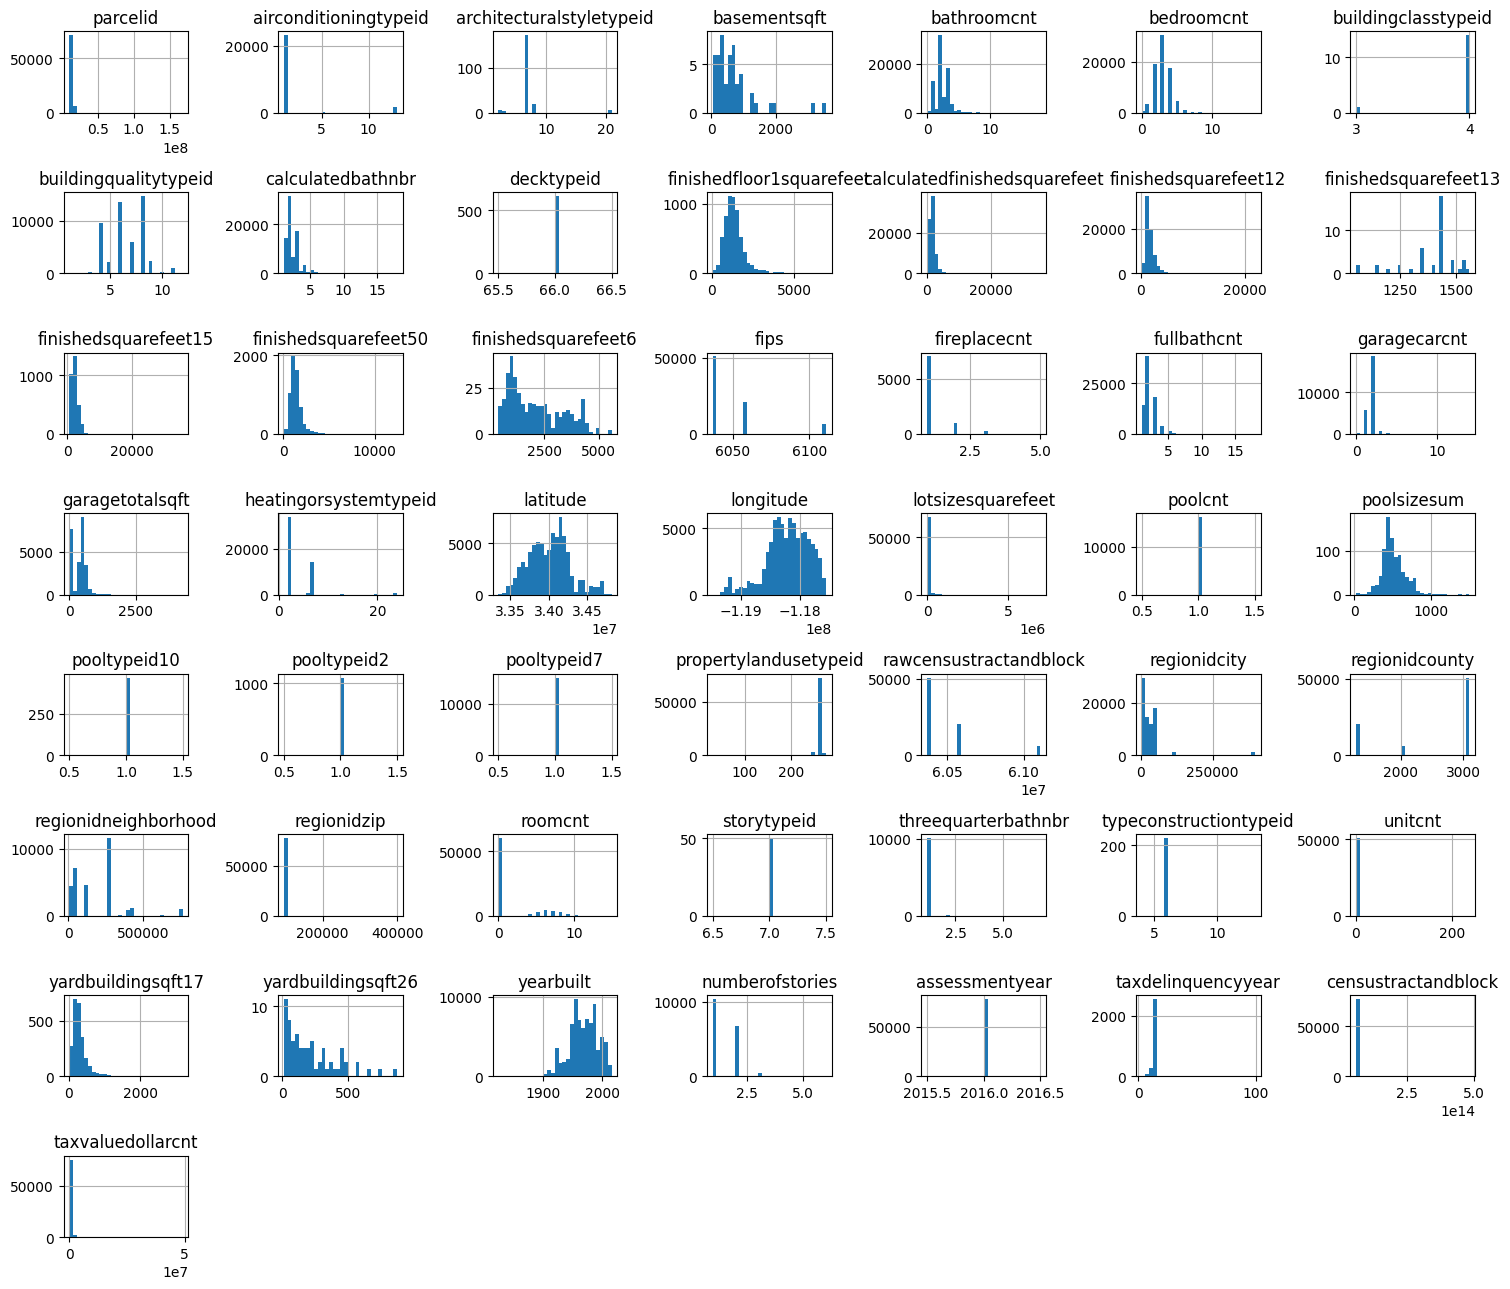

In [4]:
# Histogram of each feature in dataset
df.hist(figsize=(15, 13), bins=30)
plt.tight_layout()
plt.show()

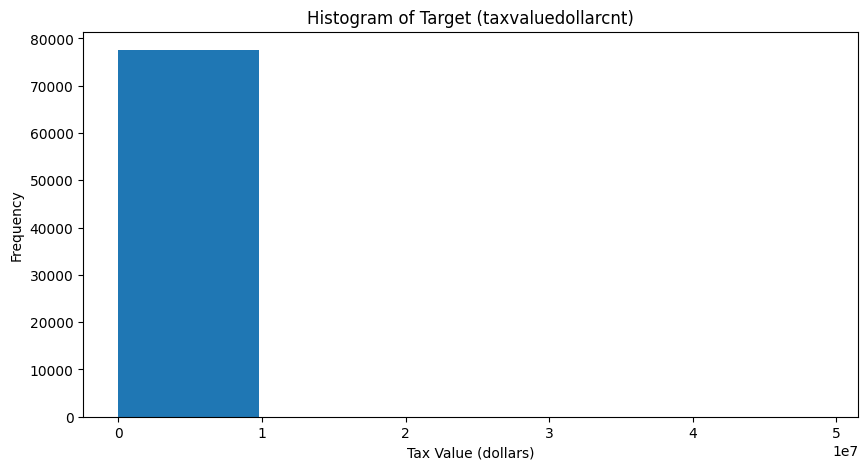

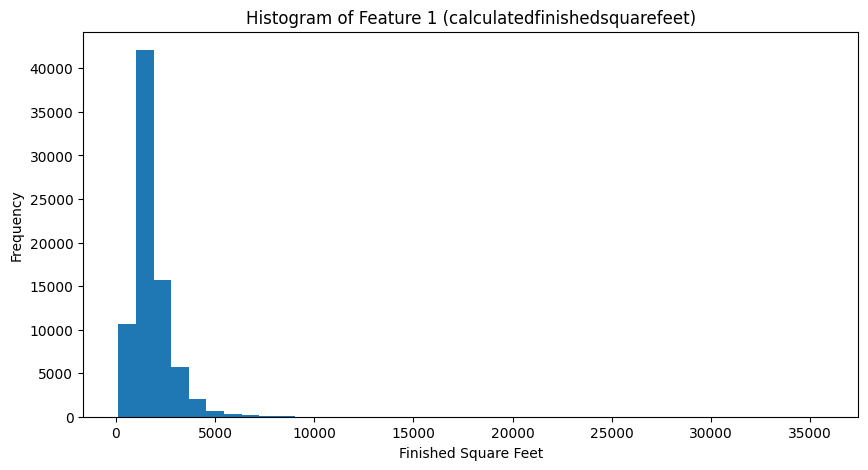

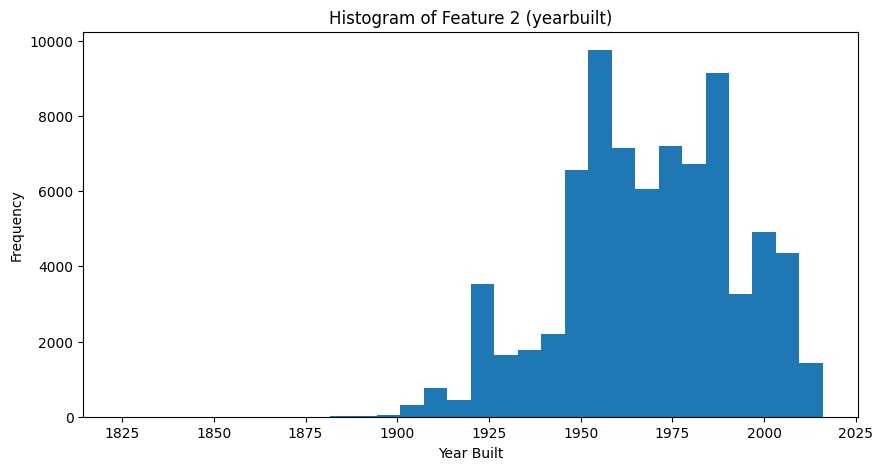

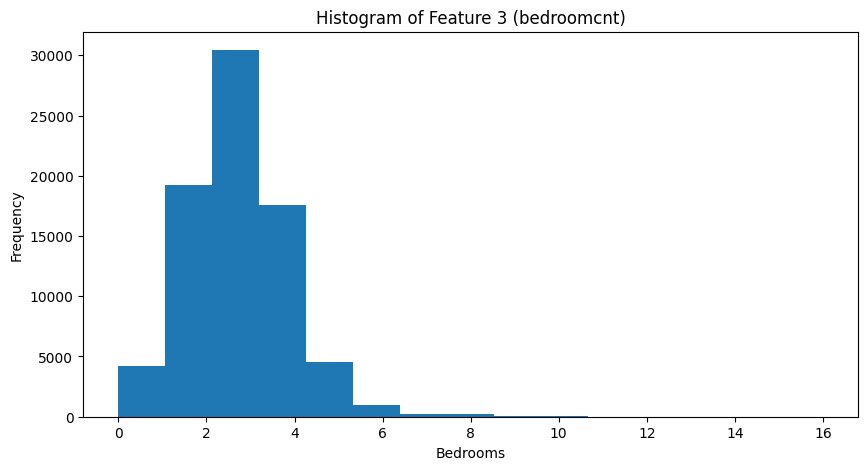

In [5]:
# Visualizations for target and 3 other features in dataset

# 1. Histogram of Target ('taxvaluedollarcnt')
plt.figure(figsize=(10,5))
plt.hist(df['taxvaluedollarcnt'], bins=5)
plt.title('Histogram of Target (taxvaluedollarcnt)')
plt.xlabel('Tax Value (dollars)')
plt.ylabel('Frequency')
plt.show()

# 2. Histogram of Feature 1 ('finishedfloor1squarefeet')
plt.figure(figsize=(10,5))
plt.hist(df['calculatedfinishedsquarefeet'], bins=40)
plt.title('Histogram of Feature 1 (calculatedfinishedsquarefeet)')
plt.xlabel('Finished Square Feet')
plt.ylabel('Frequency')
plt.show()

# 4. Histogram of Feature 2 ('yearbuilt')
plt.figure(figsize=(10,5))
plt.hist(df['yearbuilt'], bins=30)
plt.title('Histogram of Feature 2 (yearbuilt)')
plt.xlabel('Year Built')
plt.ylabel('Frequency')
plt.show()


# 3. Histogram of Feature 3 ('bedroomcnt')
plt.figure(figsize=(10,5))
plt.hist(df['bedroomcnt'], bins=15)
plt.title('Histogram of Feature 3 (bedroomcnt)')
plt.xlabel('Bedrooms')
plt.ylabel('Frequency')
plt.show()


#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


Following detailed examination of the features included in this dataset, we chose to take a further look at Feature 1 ('calculatedfinishedsquarefeet'), Feature 2 ('yearbuilt'), and Feature 3 ('bedroomcnt').
Feature 1 ('calculatedfinishedsquarefeet') shows an extremely right-skewed distribution as well as a strong right tail. This feature will be interesting to investigate as total square footage tends to positively impact home valuation and pricing.
Feature 2 ('yearbuilt') shows a slighlty left-skewed distribution. This feature will be interesting to investigate as home values tend to change with age.
Feature 3 ('bedroomcnt') also shows a right-skewed distibution. It will be interesting to investigate the relationships between bedroom count and total home square footage, bedroom count and bathroom count, and bedroom count and home tax value.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [29]:
def drop_unsuitable_features(df):

    df_dropped = df.copy()

    # List of columns to drop based on inspection
    cols_to_drop = [
        'parcelid', 
        'assessmentyear', 
        'propertyzoningdesc', 
        'censustractandblock', 
        'rawcensustractandblock',
        
        # Redundant Square Feet features (keep calculatedfinishedsquarefeet)
        'finishedsquarefeet12', 
        'finishedsquarefeet13', 
        'finishedsquarefeet15', 
        'finishedsquarefeet50', 
        'finishedsquarefeet6', 
        'finishedfloor1squarefeet', 

        # Redundant Bathroom features (keep bathroomcnt)
        'calculatedbathnbr', 
        'fullbathcnt', 
        'threequarterbathnbr', 

        # Redundant Pool features (keep poolcnt)
        'pooltypeid10', 
        'pooltypeid2', 
        'pooltypeid7', 
        'poolsizesum', 

        # Redundant Fireplace features (keep fireplacecnt)
        'fireplaceflag', 

        # Tax Delinquency features (potential leakage or not useful)
        'taxdelinquencyflag', 
        'taxdelinquencyyear',

        # High cardinality location IDs (we have lat/long)
        'regionidneighborhood', 
        'regionidzip', 
        'regionidcity', 
        'regionidcounty' 
    ]
    
    # Only drop columns that exist in the dataframe
    existing_cols_to_drop = [c for c in cols_to_drop if c in df_dropped.columns]
    
    df_dropped = df_dropped.drop(columns=existing_cols_to_drop)
    
    print(f"Dropped {len(existing_cols_to_drop)} features.")
    print(f"Original shape: {df.shape}")
    print(f"New shape: {df_dropped.shape}")
    print(f"Examples of dropped columns: {existing_cols_to_drop[:5]}")
    
    return df_dropped

# Apply the function and create a new dataframe
df_cleaned_A = drop_unsuitable_features(df)

Dropped 25 features.
Original shape: (77613, 55)
New shape: (77613, 30)
Examples of dropped columns: ['parcelid', 'assessmentyear', 'propertyzoningdesc', 'censustractandblock', 'rawcensustractandblock']


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.

Features were dropped primarily based on redundancy, unsuitability for regression, or very limited direct predictive value in their current form. `parcelid` was removed because it is only an identifier and does not generalize to new properties. `assessmentyear` was dropped because it is effectively constant, so it adds no useful signal. High-cardinality fields such as `propertyzoningdesc`, `censustractandblock`, and `rawcensustractandblock` were removed because they would require more complex handling and are not ideal for a first-pass regression baseline. Several square-footage fields and bathroom-count fields were also dropped because they were redundant with broader summary variables such as `calculatedfinishedsquarefeet` and `bathroomcnt`, which helps reduce multicollinearity. Pool subtype variables, fireplace flags, tax delinquency fields, and several location ID fields were also removed because they were either redundant, likely weak in their raw form, or less interpretable than retained alternatives such as `latitude` and `longitude`. I kept `propertycountylandusecode` so it could be encoded later as a categorical land-use feature.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [30]:
def drop_high_null_features(df, threshold=0.95):
    
    null_pct = df.isnull().mean()
    cols_to_drop = null_pct[null_pct > threshold].index.tolist()
    print(f"Dropping {len(cols_to_drop)} columns with >{int(threshold*100)}% missing values:")
    print(cols_to_drop)
    return df.drop(columns=cols_to_drop)

# Apply to the previously cleaned dataframe
df_cleaned_B = drop_high_null_features(df_cleaned_A, threshold=0.95)


Dropping 9 columns with >95% missing values:
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'hashottuborspa', 'storytypeid', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26']


#### **3.B Discussion:**

Features with more than 95% missing values were dropped. The rationale is that such features provide little usable information for modeling, and imputing so many missing values would introduce noise or bias. The columns dropped include: `architecturalstyletypeid`, `basementsqft`, `buildingclasstypeid`, `decktypeid`, `hashottuborspa`, `storytypeid`, `typeconstructiontypeid`, `yardbuildingsqft17`, and `yardbuildingsqft26`. Retaining these would not benefit the regression model due to their extreme sparsity.

### Part 3.C: Drop Problematic **samples**

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [31]:
def drop_problematic_samples(df, target_col='taxvaluedollarcnt', null_threshold=0.5, outlier_method='iqr'):
    """
    Drops problematic samples based on:
    - Too many null values (threshold: >50% by default)
    - Null values in the target
    - Outliers in the target (using IQR or z-score)
    
    Args:
        df: DataFrame to clean
        target_col: Name of the target column
        null_threshold: Proportion of null values above which to drop the row
        outlier_method: 'iqr' or 'zscore' for outlier detection
    """
    df_clean = df.copy()
    initial_count = len(df_clean)
    
    # Step 1: Drop rows with null values in the target
    null_target_count = df_clean[target_col].isnull().sum()
    df_clean = df_clean[df_clean[target_col].notnull()]
    print(f"Dropped {null_target_count} rows with null target values")
    
    # Step 2: Drop rows with too many null values
    null_per_row = df_clean.isnull().mean(axis=1)
    high_null_count = (null_per_row > null_threshold).sum()
    df_clean = df_clean[null_per_row <= null_threshold]
    print(f"Dropped {high_null_count} rows with >{null_threshold*100}% null values")
    
    # Step 3: Identify and drop outliers in target using IQR method
    if outlier_method == 'iqr':
        Q1 = df_clean[target_col].quantile(0.25)
        Q3 = df_clean[target_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_count = ((df_clean[target_col] < lower_bound) | (df_clean[target_col] > upper_bound)).sum()
        print(f"Identified {outlier_count} outliers in target (IQR method)")
        print(f"  Lower bound: ${lower_bound:,.0f}, Upper bound: ${upper_bound:,.0f}")
        
        # Drop extreme outliers (values outside 3*IQR)
        extreme_lower = Q1 - 3 * IQR
        extreme_upper = Q3 + 3 * IQR
        extreme_count = ((df_clean[target_col] < extreme_lower) | (df_clean[target_col] > extreme_upper)).sum()
        
        if extreme_count > 0:
            df_clean = df_clean[(df_clean[target_col] >= extreme_lower) & (df_clean[target_col] <= extreme_upper)]
            print(f"Dropped {extreme_count} extreme outliers (outside 3*IQR)")
    
    final_count = len(df_clean)
    total_dropped = initial_count - final_count
    print(f"\nTotal rows dropped: {total_dropped}")
    print(f"Original shape: ({initial_count}, {df.shape[1]})")
    print(f"Final shape: ({final_count}, {df.shape[1]})")
    
    return df_clean

# Apply to df_cleaned_B
df_cleaned_C = drop_problematic_samples(df_cleaned_B, target_col='taxvaluedollarcnt')


Dropped 35 rows with null target values
Dropped 185 rows with >50.0% null values
Identified 5140 outliers in target (IQR method)
  Lower bound: $-335,465, Upper bound: $1,110,943
Dropped 2318 extreme outliers (outside 3*IQR)

Total rows dropped: 2538
Original shape: (77613, 21)
Final shape: (75075, 21)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

Three categories of problematic samples were removed from the dataset. First, 35 rows with null values in the target variable (`taxvaluedollarcnt`) were dropped, as these cannot be used for supervised regression training. Second, 185 rows with more than 50% missing values across remaining features were dropped, as they provide insufficient information for modeling. Third, 2,318 extreme outliers in the target variable were removed using the 3×IQR method (values beyond Q3 + 3×IQR or Q1 − 3×IQR), which identified properties with target values outside the range of $-335,465 to $1,110,943. These extreme outliers likely represent data errors or highly unusual properties that could distort regression model fitting. Moderate outliers (between 1.5×IQR and 3×IQR bounds) were retained to preserve legitimate variation in property values. Overall, 2,538 rows (3.3% of the data) were removed, resulting in a cleaner dataset of 75,075 samples for model training.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [32]:
def impute_remaining_missing_values(df):
    """
    Impute remaining missing values with feature-type-specific strategies:
    - Numeric features: median imputation
    - Categorical features: mode imputation (fallback to 'Unknown')
    """
    df_imputed = df.copy()

    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df_imputed.select_dtypes(exclude=[np.number]).columns.tolist()

    missing_before = df_imputed.isnull().sum().sum()
    print(f"Total missing values before imputation: {missing_before}")

    if numeric_cols:
        numeric_imputer = SimpleImputer(strategy='median')
        df_imputed[numeric_cols] = numeric_imputer.fit_transform(df_imputed[numeric_cols])

    for col in categorical_cols:
        if df_imputed[col].isnull().any():
            mode_values = df_imputed[col].mode(dropna=True)
            fill_value = mode_values.iloc[0] if not mode_values.empty else 'Unknown'
            df_imputed[col] = df_imputed[col].fillna(fill_value)

    missing_after = df_imputed.isnull().sum().sum()
    print(f"Total missing values after imputation: {missing_after}")
    print(f"Shape after imputation: {df_imputed.shape}")

    return df_imputed

# Apply imputation to data cleaned in Part 3.C
df_cleaned_D = impute_remaining_missing_values(df_cleaned_C)

# Verification (top columns by remaining null count)
print(df_cleaned_D.isnull().sum().sort_values(ascending=False).head())

Total missing values before imputation: 424340
Total missing values after imputation: 0
Shape after imputation: (75075, 21)
airconditioningtypeid           0
bathroomcnt                     0
bedroomcnt                      0
buildingqualitytypeid           0
calculatedfinishedsquarefeet    0
dtype: int64


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

I used different imputation strategies based on data type. For numeric features, I used **median imputation** because housing variables are often skewed and may contain outliers, so median is more robust than mean. For categorical features, I used **mode imputation** to preserve the most common class pattern, with a fallback of **"Unknown"** if a valid mode could not be computed. This approach keeps the full dataset size while minimizing distortion from missing data. After applying imputation to `df_cleaned_C`, the resulting dataset `df_cleaned_D` has **no remaining null values**, satisfying the requirement for this section.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary.

In [33]:
def encode_propertycountylandusecode(df):
    """
    One-hot encode propertycountylandusecode if it exists.
    Leaves the dataframe unchanged if the column is missing.
    """
    df_encoded = df.copy()

    if 'propertycountylandusecode' not in df_encoded.columns:
        print("propertycountylandusecode not found. No encoding applied.")
        return df_encoded

    print("Encoding propertycountylandusecode...")
    print("Unique values before encoding:", df_encoded['propertycountylandusecode'].nunique())

    df_encoded = pd.get_dummies(
        df_encoded,
        columns=['propertycountylandusecode'],
        prefix='landuse',
        drop_first=True,
        dtype=int
    )

    encoded_cols = [col for col in df_encoded.columns if col.startswith('landuse_')]
    print(f"Created {len(encoded_cols)} encoded columns.")
    print("First few encoded columns:", encoded_cols[:10])

    return df_encoded

# Apply encoding to the imputed dataset
df_cleaned_E = encode_propertycountylandusecode(df_cleaned_D)
print(df_cleaned_E.shape)

Encoding propertycountylandusecode...
Unique values before encoding: 65
Created 64 encoded columns.
First few encoded columns: ['landuse_0101', 'landuse_0102', 'landuse_0103', 'landuse_0104', 'landuse_0105', 'landuse_0108', 'landuse_0109', 'landuse_010C', 'landuse_010D', 'landuse_010E']
(75075, 84)


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project.

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well).
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments.

Text(0.5, 1.0, 'Correlation Matrix')

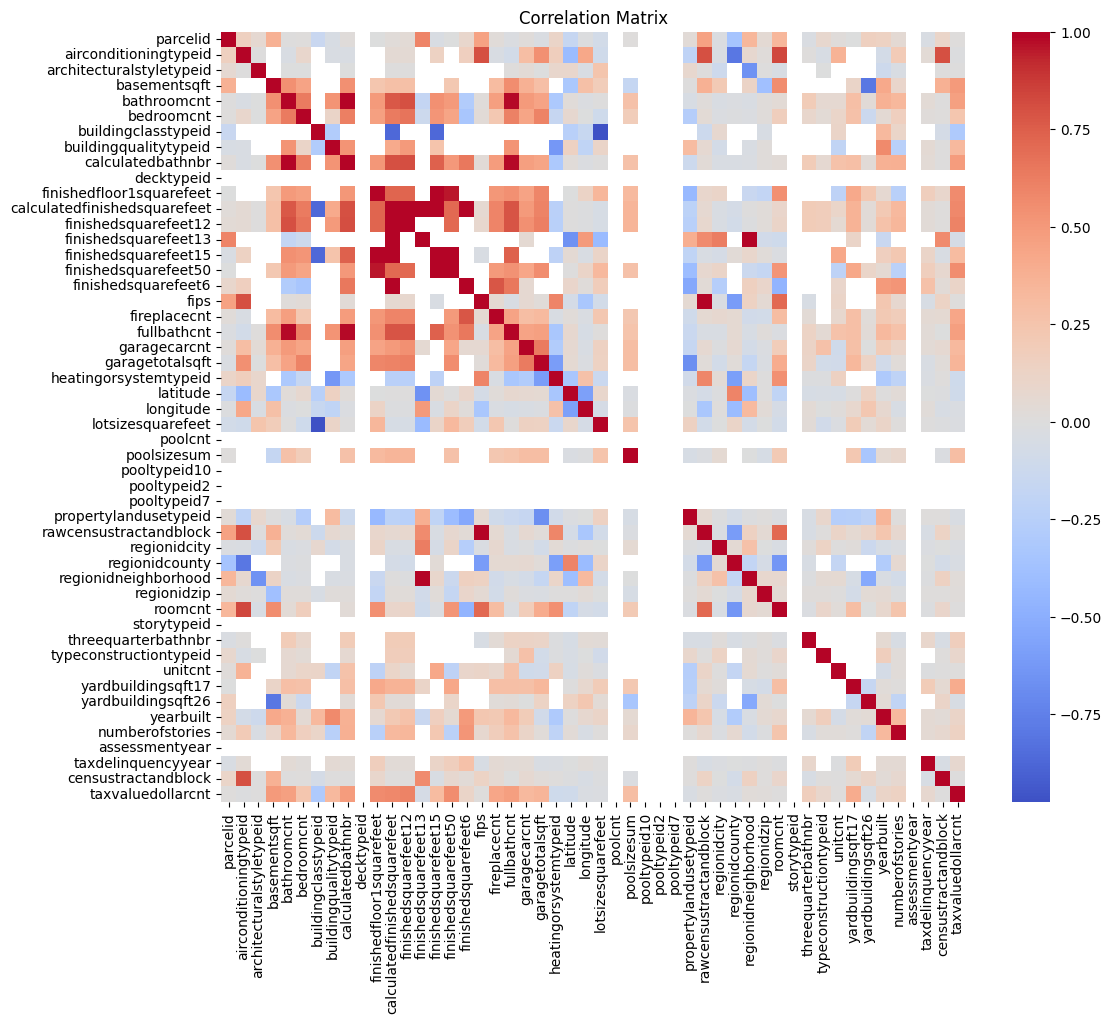

In [6]:
df_corr = df.corr(numeric_only=True)
df_corr

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")


In [7]:
## F scores

from sklearn.feature_selection import f_regression


X = df.drop(columns=["taxvaluedollarcnt"])
X = df.select_dtypes(include="number")
y = df["taxvaluedollarcnt"]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print(f_df.head(10))

ValueError: Input X contains NaN.

In [ ]:
## forward feature selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

### define X and y

model= LinearRegression()
Forward_selector = SequentialFeatureSelector(model,
                                             n_features_to_select=10,
                                             direction='forward',
                                             scoring = "neg_mean_squared_error",
                                             cv=5,
                                             n_jobs=-1)
Forward_selector.fit(X, y)
selected_forward = X.columns[Forward_selector.get_support()]
print("Forward-selected features:")
print(selected_forward)


ValueError: Input X contains NaN.
SequentialFeatureSelector does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
## Backward feature seleciton

##define X and y


model= LinearRegression()
Backward_selector = SequentialFeatureSelector(model,
                                             n_features_to_select=10,
                                             direction='backward',
                                             scoring = "neg_mean_squared_error",
                                             cv=5,
                                             n_jobs=-1)
Backward_selector.fit(X, y)
selected_backward = X.columns[Backward_selector.get_support()]
print("Forward-selected features:")
print(selected_backward)

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships.
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis.
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends.

In [ ]:
### Select 3 pairs of features with meaningful relationships



In [ ]:
### Scatter/Density Plots of selected features:

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset.
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection).
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary.

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question.

In [ ]:
#### Transformation 1



#### Transformation 2



#### Transformation 3

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

